# GA4 E-Commerce Funnel Analyse

**Dataset:** `bigquery-public-data.ga4_obfuscated_sample_ecommerce`  
**Ziel:** Den Kaufprozess von der ersten Interaktion bis zum Kauf verstehen und Optimierungspotenziale identifizieren.

---

## Struktur des Notebooks


1. Setup & Analysezeitraum
2. Überblick und Datenqualitätscheck
3. Event Inventory ## Was passiert überhaupt?
4. Standard E-Commerce Funnel (Event-Level)
5. User-Level Funnel ## Wie viele User schließen jeden Schritt ab?
6. Drop-off Analyse ## Wo werden die meisten User verloren?
7. Segmentierung ## Gibt es unterschiede bei den Geräten?
8. Revenue-Analyse
9. Visualisierungen
10. Zusammenfassung


## 1. Setup

In [27]:
#%pip install --upgrade bigframes matplotlib
import bigframes.pandas as bpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import plotly.express as px

PROJECT_ID = "funnel-analysis-demo-491115"
LOCATION = "eu"

DATE_START = '20210101'
DATE_END   = '20210131'

pd.set_option('display.max_rows', 20)

label_map = {
    'view_item':         'Produkt angesehen',
    'add_to_cart':       'In den Warenkorb',
    'begin_checkout':    'Checkout gestartet',
    'add_shipping_info': 'Versand eingegeben',
    'add_payment_info':  'Zahlung eingegeben',
    'purchase':          'Kauf abgeschlossen',
}

def run_query(query):
    return bpd.read_gbq(query)

Analysis_period = {"start": DATE_START, "end": DATE_END}

## 2. Überblick und Datenqualitätscheck

Überblick über den Datensatz und ein paar Qualitätschecks

In [79]:
run_query(f"""
SELECT
  COUNT(*)                        AS total_events,
  COUNT(DISTINCT user_pseudo_id)  AS unique_users,
  COUNT(DISTINCT event_date)      AS days_in_dataset,
  MIN(event_date)                 AS first_day,
  MAX(event_date)                 AS last_day
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
""")


,total_events,unique_users,days_in_dataset,first_day,last_day
0,1210147,94790,31,20210101,20210131


Gibt es Tage an dem keine Events stattgefunden haben?

In [ ]:
df_date_check = bpd.read_gbq(f"""
SELECT
  PARSE_DATE('%Y%m%d', event_date) AS date,
  COUNT(*) AS events
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
GROUP BY date
""")

df_date_check = df_date_check.to_pandas().sort_values('date')

df_date_check

,date,events
18,2021-01-01,22096
2,2021-01-02,23599
19,2021-01-03,24743
10,2021-01-04,31395
11,2021-01-05,42827
...,...,...
20,2021-01-27,48665
4,2021-01-28,43131
13,2021-01-29,40877
22,2021-01-30,30395


Gibt es fehlende SessionIDs? --> Nein, es gibt keine fehlende SessionIDs

In [2]:
df_session_check = bpd.read_gbq(f"""
SELECT
  COUNT(*) AS total_events,
  COUNTIF((
    SELECT ep.value.int_value
    FROM UNNEST(event_params) ep
    WHERE ep.key = 'ga_session_id') IS NULL) AS missing_session_id,
  SAFE_DIVIDE(
    COUNTIF((
      SELECT ep.value.int_value
      FROM UNNEST(event_params) ep
      WHERE ep.key = 'ga_session_id'
    ) IS NULL),
    COUNT(*)
  ) AS missing_rate
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
""")

df_session_check

,total_events,missing_session_id,missing_rate
0,1210147,0,0.0


Gibt es Events in der falschen Reihenfolge? --> Keine ungewöglichen Eventabfolgen

In [69]:
df_events_check = bpd.read_gbq(f"""
WITH ordered_events AS (
  SELECT
    user_pseudo_id,
    event_name,
    event_timestamp,
    LAG(event_name) OVER (
      PARTITION BY user_pseudo_id
      ORDER BY event_timestamp
    ) AS prev_event
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
)

SELECT
  event_name,
  prev_event,
  COUNT(*) AS occurrences
FROM ordered_events
WHERE prev_event IS NOT NULL
GROUP BY event_name, prev_event
""")

df_events_check = df_events_check.to_pandas().sort_values(['occurrences'], ascending=False)

df_events_check.head(20)

,event_name,prev_event,occurrences
82,page_view,user_engagement,135435
73,user_engagement,page_view,105103
138,scroll,page_view,82478
6,user_engagement,scroll,71486
147,page_view,session_start,68258
61,page_view,first_visit,51826
116,page_view,page_view,46346
49,view_promotion,page_view,43959
121,session_start,page_view,42096
64,page_view,scroll,38309


Gibt es fehlende Umsätze? --> Ja, gibt es und sogar relativ viel mit knapp 25%. Bei diesen hohen Prozenten muss man das nachverfolgen

In [70]:
df_revenue_check = bpd.read_gbq(f"""
SELECT
  COUNT(*) AS total_purchases,

  COUNTIF(
    COALESCE(
      (SELECT ep.value.double_value FROM UNNEST(event_params) ep WHERE ep.key = 'value'),
      (SELECT ep.value.int_value    FROM UNNEST(event_params) ep WHERE ep.key = 'value')
    ) IS NULL
  ) AS missing_value,

  SAFE_DIVIDE(
    COUNTIF(
      COALESCE(
        (SELECT ep.value.double_value FROM UNNEST(event_params) ep WHERE ep.key = 'value'),
        (SELECT ep.value.int_value    FROM UNNEST(event_params) ep WHERE ep.key = 'value')
      ) IS NULL
    ),
    COUNT(*)
  ) AS missing_rate

FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name = 'purchase'
  AND _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
""")

df_revenue_check

,total_purchases,missing_value,missing_rate
0,1204,300,0.249169


Gibt es Einkäufe ohne Produkte? --> Obwohl bei 25% der Einkäufe der Umsatz fehlt, hat jeder Einkauf mindestens 1 Item. 

In [71]:
df_purchase_check = bpd.read_gbq(f"""
SELECT
  COUNT(*) AS total_purchases,
  COUNTIF(ARRAY_LENGTH(items) > 0) AS with_items,
  COUNTIF(ARRAY_LENGTH(items) = 0 OR items IS NULL) AS without_items
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name = 'purchase'
  AND _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  """)
df_purchase_check

,total_purchases,with_items,without_items
0,1204,1204,0


Wie viele Purchase-Events haben zwar Items aber entweder keine Werte oder die Werte 0 bei Preis und Quantität? --> Es ist sehr interessant, das genau die 300 Purchase Events die für die 25% Missing Values verantworltich sind zwar Items haben aber sowohl den Wert NULL bei Preis und Quanität haben. Dieses Datenproblem kann unter verschiedenen Umständen in diesen Datensatz gelangt sein. Zum Beispiel dass das Event ausgelöst wurde bevor alle Daten verfügbar waren, Probleme beim Tracking oder das eben bewusst von Google fehlerhafte Daten mit reingebracht wurden.

In [73]:
df_item_check = bpd.read_gbq(f"""
SELECT
  COUNT(*) AS total,

  COUNTIF(item.price IS NULL) AS price_null,
  COUNTIF(item.quantity IS NULL) AS quantity_null,

  COUNTIF(item.price = 0) AS price_zero,
  COUNTIF(item.quantity = 0) AS quantity_zero

FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`,
UNNEST(items) AS item

WHERE event_name = 'purchase'
  AND COALESCE(
    (SELECT ep.value.double_value FROM UNNEST(event_params) ep WHERE ep.key = 'value'),
    (SELECT ep.value.int_value FROM UNNEST(event_params) ep WHERE ep.key = 'value')
  ) IS NULL
  AND _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  """)

df_item_check

,total,price_null,quantity_null,price_zero,quantity_zero
0,300,300,300,0,0


## 3. Event Inventory

Welche Events gibt es überhaupt?

In [4]:
df_events = bpd.read_gbq(f"""
SELECT
  event_name,
  COUNT(*)                        AS event_count,
  COUNT(DISTINCT user_pseudo_id)  AS unique_users,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage_of_all_events
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
GROUP BY event_name
""")


df_events = df_events.sort_values(by='event_count', ascending=False)
df_events.head(20).to_pandas()

,event_name,event_count,unique_users,percentage_of_all_events
8,page_view,419004,94630,34.62
6,user_engagement,250097,72574,20.67
5,scroll,138997,45594,11.49
11,session_start,116549,93552,9.63
1,first_visit,88873,88830,7.34
16,view_item,86971,19629,7.19
10,view_promotion,53885,32131,4.45
4,add_to_cart,15522,3832,1.28
0,begin_checkout,11034,1924,0.91
14,select_item,10229,4991,0.85


## 4. Funnel Analyse auf der Event-Ebene

In dieser Analyse wird geschaut, wie oft jedes Event aufgerufen wurde. Im gegensatz zu der User und Session Ebene wird hier nicht darauf geachtet, ob dieselben Nutzer oder Session die Schritte durchlaufen. Das heißt, ein User kann mehrmals ein Event ausführen und es muss in keiner bestimmten reihenfolge stattfinden.

Da der Event-Funnel keine echte Konvertierung misst, wird im nächsten Schritt ein User-basierter Funnel berechnet, um die tatsächliche Konvertierung zwischen den Schritten zu analysieren.

In [7]:
FUNNEL_STEPS = [
    'view_item',
    'add_to_cart',
    'begin_checkout',
    'add_shipping_info',
    'add_payment_info',
    'purchase'
]

df_funnel_events = bpd.read_gbq(f"""
    SELECT
      event_name,
      COUNT(*) AS events
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
      AND event_name IN (
        'view_item', 'add_to_cart',
        'begin_checkout', 'add_shipping_info',
        'add_payment_info', 'purchase'
      )
    GROUP BY event_name
""")

df_funnel_events = (
    df_funnel_events
    .to_pandas()
    .set_index('event_name')
    .reindex(FUNNEL_STEPS)
    .reset_index()
)

df_funnel_events

,event_name,events
0,view_item,86971
1,add_to_cart,15522
2,begin_checkout,11034
3,add_shipping_info,3952
4,add_payment_info,2841
5,purchase,1204


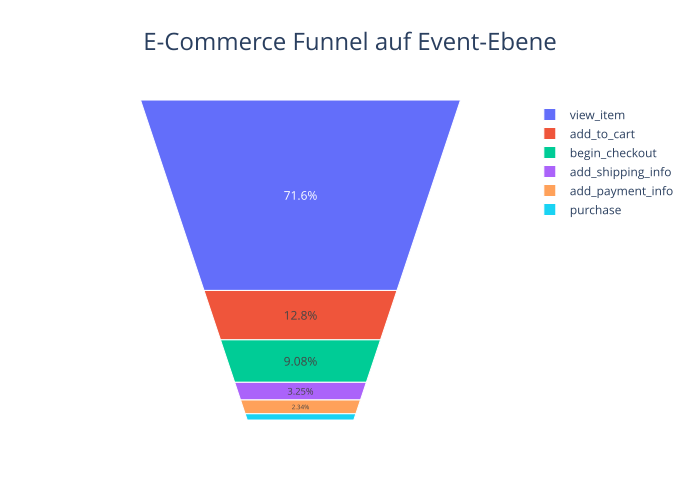

In [11]:
import plotly.express as px

label_map = {
    'view_item':         'Produkt angesehen',
    'add_to_cart':       'In den Warenkorb',
    'begin_checkout':    'Checkout gestartet',
    'add_shipping_info': 'Versand eingegeben',
    'add_payment_info':  'Zahlung eingegeben',
    'purchase':          'Kauf abgeschlossen',
}

df_funnel_plot = df_funnel_events.copy()
df_funnel_plot['step'] = df_funnel_plot['event_name'].map(label_map)

fig = px.funnel_area(
    df_funnel_plot,
    values='events',
    names='event_name',
    title='E-Commerce Funnel auf Event-Ebene')

fig.update_layout(title_x=0.5, title_font_size=24)

fig.write_image("../figures/funnel_events_overview.png", scale=2)
fig.show(renderer='svg')

In [46]:
df_funnel_events['events_rel'] = df_funnel_events['events'] / df_funnel_events['events'].iloc[0] * 100

df_funnel_events['label'] = df_funnel_events['events_rel'].round(2).astype(str) + "%"

fig = px.funnel(df_funnel_events, y=df_funnel_events['event_name'].map(label_map), x='events_rel', title='E-Commerce Funnel auf Event-Ebene')

fig.update_traces(
    text=df_funnel_events['events_rel'].map(lambda x: f"{x:.2f}%"),
    textinfo="text" 
    
)

fig.update_layout(
    xaxis_title='Anteil der Nutzer in %',
    yaxis_title='Funnel-Schritte',
    title_x=0.5,    
)

fig.show()


## 5. Funnel Analyse auf User-Ebene

Dieser Funnel wird auf User-Ebene berechnet, da auf Event-Eben nicht auf die User-Journey geachtet wird.
Dazu wird der frühste Timestamp pro Event-Typ bestimmt und ein User durchläuft den Funnel, insofern das Event exisitiert und die Events in der zeitlich richtigen Reihenfolge sind.

Die einzige Einschränkung dabei ist dass das ganze auf den Analysezeitraum geachtet wird und nicht per Session. Diese folgt danach
Es ist jedoch trotzdem interessant das ein Kunde sich z.B am Montag ein Produkt anschaut, am Mittwoch es in den Warenkorb legt und am Samstag dann kauft. 

Daraus lassen sich Schlüsse zur genrellen Conversion-Fähigkeit der User ziehen.

In [24]:
df_ordered_funnel = bpd.read_gbq(f"""
WITH user_steps AS (
  SELECT
    user_pseudo_id,
    MIN(IF(event_name = 'view_item',         event_timestamp, NULL)) AS ts_view_item,
    MIN(IF(event_name = 'add_to_cart',       event_timestamp, NULL)) AS ts_add_to_cart,
    MIN(IF(event_name = 'begin_checkout',    event_timestamp, NULL)) AS ts_begin_checkout,
    MIN(IF(event_name = 'add_shipping_info', event_timestamp, NULL)) AS ts_add_shipping_info,
    MIN(IF(event_name = 'add_payment_info',  event_timestamp, NULL)) AS ts_add_payment_info,
    MIN(IF(event_name = 'purchase',          event_timestamp, NULL)) AS ts_purchase
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  GROUP BY user_pseudo_id
)
SELECT
  COUNTIF(ts_view_item IS NOT NULL)                                                                       AS view_item,
  COUNTIF(ts_view_item IS NOT NULL
    AND ts_add_to_cart       > ts_view_item)                                                              AS add_to_cart,
  COUNTIF(ts_view_item IS NOT NULL
    AND ts_add_to_cart       > ts_view_item
    AND ts_begin_checkout    > ts_add_to_cart)                                                            AS begin_checkout,
  COUNTIF(ts_view_item IS NOT NULL
    AND ts_add_to_cart       > ts_view_item
    AND ts_begin_checkout    > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout)                                                        AS add_shipping_info,
  COUNTIF(ts_view_item IS NOT NULL
    AND ts_add_to_cart       > ts_view_item
    AND ts_begin_checkout    > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout
    AND ts_add_payment_info  > ts_add_shipping_info)                                                      AS add_payment_info,
  COUNTIF(ts_view_item IS NOT NULL
    AND ts_add_to_cart       > ts_view_item
    AND ts_begin_checkout    > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout
    AND ts_add_payment_info  > ts_add_shipping_info
    AND ts_purchase          > ts_add_payment_info)                                                       AS purchase
FROM user_steps
""")

df_user_funnel = df_ordered_funnel.to_pandas().melt(var_name='step', value_name='users')

df_user_funnel



,step,users
0,view_item,19629
1,add_to_cart,3295
2,begin_checkout,1217
3,add_shipping_info,252
4,add_payment_info,174
5,purchase,141


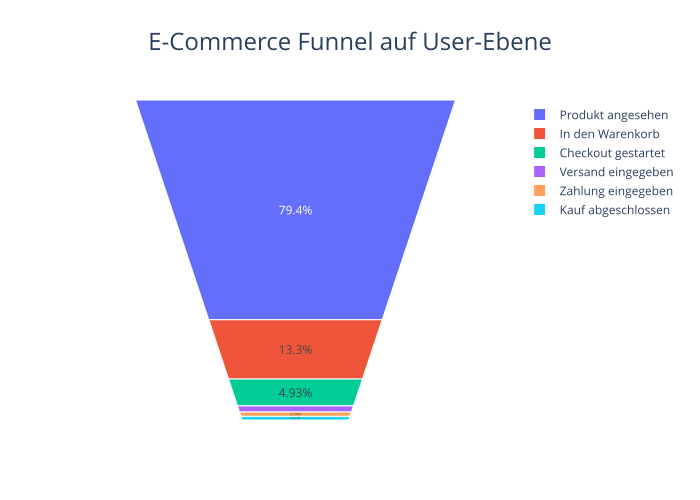

In [ ]:
import plotly.express as px



df_funnel_plot = df_user_funnel.copy()
df_funnel_plot['step'] = df_funnel_plot['step'].map(label_map)

fig = px.funnel_area(
    df_funnel_plot,
    values='users',
    names='step',
    title='E-Commerce Funnel auf User-Ebene')

fig.update_layout(title_x=0.5, title_font_size=24)

fig.write_image("../figures/funnel_users_overview.png", scale=2)
fig.show(renderer='svg')

In [42]:
df_user_funnel['users_rel'] = df_user_funnel['users'] / df_user_funnel['users'].iloc[0] * 100

df_user_funnel['label'] = df_user_funnel['users_rel'].round(2).astype(str) + "%"

fig = px.funnel(df_user_funnel, y=df_user_funnel['step'].map(label_map), x='users_rel', title='E-Commerce Funnel auf User-Ebene')


fig.update_traces(
    text=df_user_funnel['users_rel'].map(lambda x: f"{x:.2f}%"),
    textinfo="text"  # 🔥 verhindert doppelte Anzeige
    
)

fig.update_layout(
    xaxis_title='Anteil der Nutzer in %',
    yaxis_title='Funnel-Schritte',
    title_x=0.5,    
)

fig.show()


## Funnel Analyse auf Session-Ebene

Im gegensatz zu der Funnel Analyse auf User-Ebene, wird bei dieser Funnel Analyse speziell auf den Zeitraum einer Session geschaut.

Damit zeigt diese Analyse, wie gut ein Nutzer innerhalb einer Session konvertiert.

In [48]:
df_session_funnel_raw = bpd.read_gbq(f"""
WITH events_with_session AS (
  SELECT
    user_pseudo_id,
    (
      SELECT ep.value.int_value
      FROM UNNEST(event_params) AS ep
      WHERE ep.key = 'ga_session_id'
    ) AS ga_session_id,
    event_name,
    event_timestamp
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
    AND event_name IN (
      'view_item',
      'add_to_cart',
      'begin_checkout',
      'add_shipping_info',
      'add_payment_info',
      'purchase'
    )
),

session_steps AS (
  SELECT
    user_pseudo_id,
    ga_session_id,
    MIN(IF(event_name = 'view_item',         event_timestamp, NULL)) AS ts_view_item,
    MIN(IF(event_name = 'add_to_cart',       event_timestamp, NULL)) AS ts_add_to_cart,
    MIN(IF(event_name = 'begin_checkout',    event_timestamp, NULL)) AS ts_begin_checkout,
    MIN(IF(event_name = 'add_shipping_info', event_timestamp, NULL)) AS ts_add_shipping_info,
    MIN(IF(event_name = 'add_payment_info',  event_timestamp, NULL)) AS ts_add_payment_info,
    MIN(IF(event_name = 'purchase',          event_timestamp, NULL)) AS ts_purchase
  FROM events_with_session
  WHERE ga_session_id IS NOT NULL
  GROUP BY user_pseudo_id, ga_session_id
)

SELECT
  COUNTIF(ts_view_item IS NOT NULL) AS view_item,
  COUNTIF(
    ts_view_item IS NOT NULL
    AND ts_add_to_cart > ts_view_item
  ) AS add_to_cart,
  COUNTIF(
    ts_view_item IS NOT NULL
    AND ts_add_to_cart > ts_view_item
    AND ts_begin_checkout > ts_add_to_cart
  ) AS begin_checkout,
  COUNTIF(
    ts_view_item IS NOT NULL
    AND ts_add_to_cart > ts_view_item
    AND ts_begin_checkout > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout
  ) AS add_shipping_info,
  COUNTIF(
    ts_view_item IS NOT NULL
    AND ts_add_to_cart > ts_view_item
    AND ts_begin_checkout > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout
    AND ts_add_payment_info > ts_add_shipping_info
  ) AS add_payment_info,
  COUNTIF(
    ts_view_item IS NOT NULL
    AND ts_add_to_cart > ts_view_item
    AND ts_begin_checkout > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout
    AND ts_add_payment_info > ts_add_shipping_info
    AND ts_purchase > ts_add_payment_info
  ) AS purchase
FROM session_steps
""")

df_session_funnel = df_session_funnel_raw.to_pandas().melt(
    var_name='step',
    value_name='sessions'
)

df_session_funnel

,step,sessions
0,view_item,23105
1,add_to_cart,3805
2,begin_checkout,1265
3,add_shipping_info,268
4,add_payment_info,188
5,purchase,135


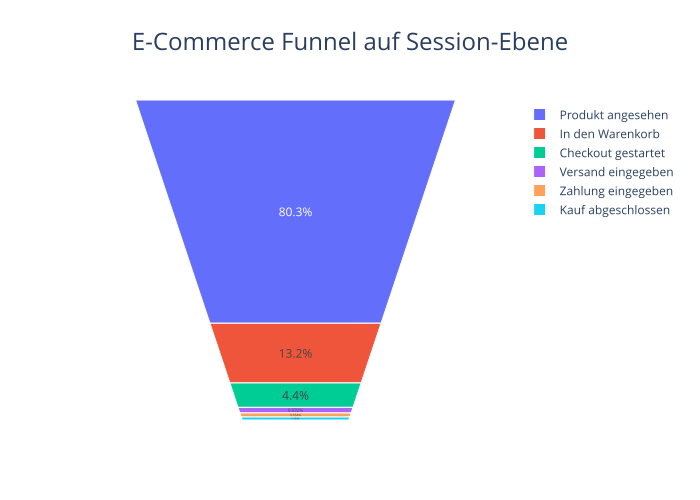

In [51]:
import plotly.express as px

df_funnel_plot = df_session_funnel.copy()
df_funnel_plot['step'] = df_funnel_plot['step'].map(label_map)

fig = px.funnel_area(
    df_funnel_plot,
    values='sessions',
    names='step',
    title='E-Commerce Funnel auf Session-Ebene')

fig.update_layout(title_x=0.5, title_font_size=24)

fig.write_image("../figures/funnel_sessions_overview.png", scale=2)
fig.show(renderer='svg')

In [49]:
df_session_funnel['sessions_rel'] = df_session_funnel['sessions'] / df_session_funnel['sessions'].iloc[0] * 100

df_session_funnel['label'] = df_session_funnel['sessions_rel'].round(2).astype(str) + "%"

fig = px.funnel(df_session_funnel, y=df_session_funnel['step'].map(label_map), x='sessions_rel', title='E-Commerce Funnel auf Session-Ebene')
fig.update_traces(
    text=df_session_funnel['sessions_rel'].map(lambda x: f"{x:.2f}%"),
    textinfo="text" 
    
)

fig.update_layout(
    xaxis_title='Anteil der Nutzer in %',
    yaxis_title='Funnel-Schritte',
    title_x=0.5,    
)

fig.show()


## 6. Drop-off Analyse

Um die Problembereiche zu erkennen, wird jetzt eine Drop-Off Analyse durchgeführt.

- **`pct_of_start`** beschreibt wie viel % der initialen Session-User noch dabei sind
- **`step_conversion_pct`** beschreibt wie viel % der User des *vorherigen* Schritts weitergehen

Ein niedriger `step_conversion_pct` zeigt, wo der größte Handlungsbedarf besteht.

In [25]:
df_dropoff = df_user_funnel.copy()

df_dropoff['pct_of_start']      = (df_dropoff['users'] / df_dropoff['users'].iloc[0] * 100).round(2)
df_dropoff['step_conversion_pct'] = (df_dropoff['users'] / df_dropoff['users'].shift(1) * 100).round(2)
df_dropoff['dropoff_users']     = df_dropoff['users'].shift(1) - df_dropoff['users']

df_dropoff

,step,users,pct_of_start,step_conversion_pct,dropoff_users
0,view_item,19629,100.0,<NA>,<NA>
1,add_to_cart,3295,16.79,16.79,16334
2,begin_checkout,1217,6.2,36.93,2078
3,add_shipping_info,252,1.28,20.71,965
4,add_payment_info,174,0.89,69.05,78
5,purchase,141,0.72,81.03,33


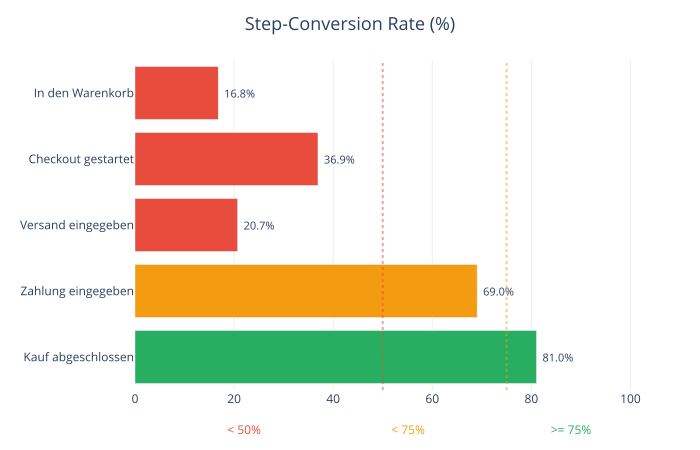

In [36]:
import pandas as pd
import plotly.graph_objects as go

df_plot = df_dropoff.copy()
df_plot["label"] = df_plot["step"].map(label_map)
x_max = df_plot["users"].max()


def de_int(x):
    return f"{int(x):,}".replace(",", ".")

fig1 = go.Figure()

# Einheitliche Grundfarbe für Ruhe im Chart
bar_color = "#4F8EDC"

fig1.add_trace(go.Bar(
    y=df_plot["label"][::-1],
    x=df_plot["users"][::-1],
    orientation="h",
    marker=dict(
        color=bar_color,
        line=dict(color="white", width=1.5)
    ),
    text=[de_int(u) for u in df_plot["users"][::-1]],
    textposition="inside",
    insidetextanchor="middle",
    textfont=dict(color="white", size=13),
    cliponaxis=False,
    hovertemplate="<b>%{y}</b><br>User: %{x:,.0f}<extra></extra>",
    showlegend=False,
))

# Annotationen für Drop-offs
x_max = df_plot["users"].max()
x_offset = x_max * 0.02

for _, row in df_plot.iterrows():
    if pd.isna(row["dropoff_users"]) or pd.isna(row["step_conversion_pct"]):
        continue

    drop_pct = 100 - float(row["step_conversion_pct"])

    text = f"{drop_pct:.0f}% Drop-off"
    color = "#E74C3C"

    # 👉 Dynamischer Abstand
    offset = max(x_max * 0.03, 300)

    fig1.add_annotation(
        x=row["users"] + offset,
        y=row["label"],
        text=text,
        showarrow=False,
        xanchor="left",
        yanchor="middle",
        font=dict(size=13, color=color),
    )

for _, row in df_plot.iterrows():
    if row["users"] < x_max * 0.06:
        fig1.add_annotation(
            x=row["users"] + x_offset * 0.2,
            y=row["label"],
            text=de_int(row["users"]),
            showarrow=False,
            xanchor="left",
            yanchor="middle",
            font=dict(size=11, color="#2C3E50"),
        )

fig1.update_layout(
    title=dict(
        text="Funnel: User pro Ebene und Drop-offs",
        x=0.5,
        xanchor="center",
        font=dict(size=24, color="#23395B")
    ),
    height=560,
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=40, r=160, t=80, b=50),
    bargap=0.20,
    xaxis=dict(
        title="Anzahl User",
        showgrid=True,
        gridcolor="rgba(0,0,0,0.08)",
        zeroline=False,
        tickformat="~s"
    ),
    yaxis=dict(
        title="",
        tickfont=dict(size=16, color="#2A3F5F"),
        automargin=True
    ),
    font=dict(family="Arial, sans-serif", color="#2A3F5F")
)

fig1.show()

df_conv = df_plot[df_plot['step_conversion_pct'].notna() & (df_plot['step_conversion_pct'].astype(str) != '<NA>')].copy()
df_conv['step_conversion_pct'] = df_conv['step_conversion_pct'].astype(float)
conv_colors = [conv_color(v) for v in df_conv['step_conversion_pct']]

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    y=df_conv['label'][::-1],
    x=df_conv['step_conversion_pct'][::-1],
    orientation='h',
    marker_color=conv_colors[::-1],
    text=[f"{v:.1f}%" for v in df_conv['step_conversion_pct'][::-1]],
    textposition='outside',
    textfont=dict(size=11),
    name='Conversion',
    showlegend=False,
))

fig2.add_vline(x=50, line_dash='dot', line_color='#e74c3c', opacity=0.5)
fig2.add_vline(x=75, line_dash='dot', line_color='#f39c12', opacity=0.5)


for x_pos, color, label in [
    (0.2, '#e74c3c', '< 50%'),
    (0.5, '#f39c12', '< 75%'),
    (0.8, '#27ae60', '>= 75%'),
]:
    fig2.add_annotation(
        x=x_pos, y=-0.15, xref='paper', yref='paper',
        text=label, showarrow=False,
        font=dict(size=12, color=color), xanchor='center',
    )

fig2.update_layout(
    title=dict(text='Step-Conversion Rate (%)', x=0.5, font=dict(size=18)),
    height=450, plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(range=[0, 110], showgrid=True, gridcolor='#eeeeee'),
    margin=dict(l=20, r=20, t=60, b=60),
)

fig2.write_image("../figures/funnel_conversion.png", scale=2)
fig2.show(renderer='svg')

## 6. Zeitdimension: Wie lange braucht ein User pro Schritt, wie lange dauert durchschnittliche eine Customer Journey?

In [14]:
## Wie lange braucht ein User pro Schritt?
df_time = bpd.read_gbq(f"""
WITH user_steps AS (
  SELECT
    user_pseudo_id,
    MIN(IF(event_name = 'view_item',         event_timestamp, NULL)) AS ts_view,
    MIN(IF(event_name = 'add_to_cart',       event_timestamp, NULL)) AS ts_cart,
    MIN(IF(event_name = 'begin_checkout',    event_timestamp, NULL)) AS ts_checkout,
    MIN(IF(event_name = 'add_shipping_info', event_timestamp, NULL)) AS ts_shipping,
    MIN(IF(event_name = 'add_payment_info',  event_timestamp, NULL)) AS ts_payment,
    MIN(IF(event_name = 'purchase',          event_timestamp, NULL)) AS ts_purchase
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
    AND event_name IN ('view_item','add_to_cart','begin_checkout',
                       'add_shipping_info','add_payment_info','purchase')
  GROUP BY user_pseudo_id
)

SELECT
  ROUND(AVG((ts_cart     - ts_view)     / 1e6 / 60), 1) AS avg_min_view_to_cart,
  ROUND(AVG((ts_checkout - ts_cart)     / 1e6 / 60), 1) AS avg_min_cart_to_checkout,
  ROUND(AVG((ts_shipping - ts_checkout) / 1e6 / 60), 1) AS avg_min_checkout_to_shipping,
  ROUND(AVG((ts_payment  - ts_shipping) / 1e6 / 60), 1) AS avg_min_shipping_to_payment,
  ROUND(AVG((ts_purchase - ts_payment)  / 1e6 / 60), 1) AS avg_min_payment_to_purchase,
  ROUND(AVG((ts_purchase - ts_view)     / 1e6 / 60 / 60 / 24), 1) AS avg_days_total_journey
FROM user_steps
WHERE ts_view IS NOT NULL
  AND ts_cart     > ts_view
  AND ts_checkout > ts_cart
  AND ts_shipping >=ts_checkout
  AND ts_payment  > ts_shipping
  AND ts_purchase > ts_payment
""")

df_time_pd = df_time.to_pandas()

time_labels = {
    'avg_min_view_to_cart':          'View → Warenkorb',
    'avg_min_cart_to_checkout':      'Warenkorb → Checkout',
    'avg_min_checkout_to_shipping':  'Checkout → Versand',
    'avg_min_shipping_to_payment':   'Versand → Zahlung',
    'avg_min_payment_to_purchase':   'Zahlung → Kauf',
}
df_time_long = df_time_pd[list(time_labels.keys())].melt(var_name='transition', value_name='avg_minutes')
df_time_long['label'] = df_time_long['transition'].map(time_labels)
df_time_long


,transition,avg_minutes,label
0,avg_min_view_to_cart,767.5,View → Warenkorb
1,avg_min_cart_to_checkout,876.5,Warenkorb → Checkout
2,avg_min_checkout_to_shipping,0.0,Checkout → Versand
3,avg_min_shipping_to_payment,15.3,Versand → Zahlung
4,avg_min_payment_to_purchase,222.9,Zahlung → Kauf


In [ ]:
fig_time = px.bar(
    df_time_long.sort_values('avg_minutes'),
    x='avg_minutes',
    y='label',
    orientation='h',
    text=df_time_long.sort_values('avg_minutes')['avg_minutes'].apply(lambda x: f'{x:.0f} min'),
    color='avg_minutes',
    color_continuous_scale='RdYlGn_r',
    labels={'avg_minutes': 'Ø Minuten bis zum nächsten Schritt', 'label': ''},
    title='Ø Zeit zwischen Funnel-Schritten (nur kaufende User)',
)
fig_time.update_traces(textposition='outside')
fig_time.update_layout(
    title_x=0.5, title_font_size=18,
    coloraxis_showscale=False,
    plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#eeeeee'),
)
fig_time.write_image("../figures/funnel_time_between_steps.png", scale=2)
fig_time.show()

total_days = df_time_pd['avg_days_total_journey'].iloc[0]
print(f"\nGesamte Customer Journey (View → Kauf): Ø {total_days} Tage")



Gesamte Customer Journey (View → Kauf): Ø 1.3 Tage


## 7. Segmentierung nach Geräte, Tracking Source, Neue vs Wiederkehren User, Ländern

In [16]:
df_device = bpd.read_gbq(f"""
SELECT
  device.category                                                                AS device_category,
  COUNT(DISTINCT user_pseudo_id)                                                 AS users,
  COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL))              AS purchases,
  ROUND(COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL)) 
        * 100.0 / NULLIF(COUNT(DISTINCT user_pseudo_id), 0), 2)                 AS conversion_rate_pct
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
CROSS JOIN UNNEST(event_params) AS p
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
GROUP BY device.category
""")
df_device = df_device.sort_values(by='conversion_rate_pct', ascending=False)
df_device.to_pandas()

,device_category,users,purchases,conversion_rate_pct
0,tablet,2166,29,1.34
2,mobile,37934,450,1.19
1,desktop,55236,594,1.08


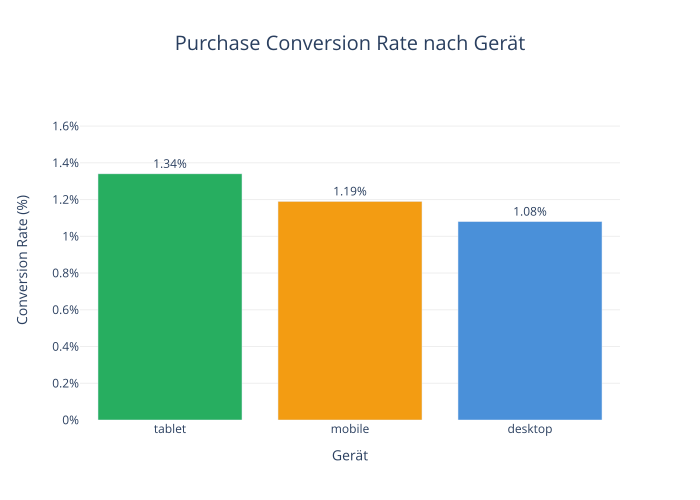

In [17]:
df_dev_pd = df_device.to_pandas().sort_values('conversion_rate_pct', ascending=False)

fig = px.bar(
    df_dev_pd,
    x='device_category',
    y='conversion_rate_pct',
    text=df_dev_pd['conversion_rate_pct'].apply(lambda x: f'{x:.2f}%'),
    color='device_category',
    color_discrete_map={'desktop': '#4a90d9', 'mobile': '#f39c12', 'tablet': '#27ae60'},
    labels={'device_category': 'Gerät', 'conversion_rate_pct': 'Conversion Rate (%)'},
    title='Purchase Conversion Rate nach Gerät',
)

fig.update_traces(textposition='outside')
fig.update_layout(
    title_x=0.5,
    title_font_size=20,
    showlegend=False,
    yaxis=dict(ticksuffix='%', range=[0, df_dev_pd['conversion_rate_pct'].max() * 1.3]),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis_showgrid=True,
    yaxis_gridcolor='#eeeeee',
)

fig.write_image('../figures/device_conversion_rate.png', scale=2, width=600, height=400)
fig.show(renderer='svg')

In [30]:
df_traffic = bpd.read_gbq(f"""
WITH user_channel AS (
  SELECT
    user_pseudo_id,
    MAX(IF(event_name = 'session_start',
      (SELECT ep.value.string_value FROM UNNEST(event_params) ep WHERE ep.key = 'medium'),
      NULL)) AS medium
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  GROUP BY user_pseudo_id
)

SELECT
  COALESCE(medium, '(none)') AS medium,
  COUNT(DISTINCT e.user_pseudo_id)                                                    AS users,
  COUNT(DISTINCT IF(e.event_name = 'add_to_cart',  e.user_pseudo_id, NULL))          AS added_to_cart,
  COUNT(DISTINCT IF(e.event_name = 'purchase',     e.user_pseudo_id, NULL))          AS purchases,
  ROUND(COUNT(DISTINCT IF(e.event_name = 'purchase', e.user_pseudo_id, NULL))
        * 100.0 / NULLIF(COUNT(DISTINCT e.user_pseudo_id), 0), 2)                   AS conversion_rate_pct
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*` e
JOIN user_channel uc USING (user_pseudo_id)
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
GROUP BY medium
HAVING COUNT(DISTINCT e.user_pseudo_id) >= 100
ORDER BY conversion_rate_pct DESC
""")

df_traffic_pd = df_traffic.to_pandas()
df_traffic_pd
print("\nKeine weitere Traffic-Analyse möglich, da es keine Daten dafür gibt.")



Keine weitere Traffic-Analyse möglich, da es keine Daten dafür gibt.


In [19]:
df_new_ret = bpd.read_gbq(f"""
WITH user_type AS (
  SELECT
    user_pseudo_id,
    MAX(IF(event_name = 'first_visit', 1, 0)) AS is_new_user
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  GROUP BY user_pseudo_id
)

SELECT
  IF(ut.is_new_user = 1, 'Neue User', 'Wiederkehrende User') AS user_type,
  COUNT(DISTINCT e.user_pseudo_id)                                                 AS total_users,
  COUNT(DISTINCT IF(e.event_name = 'add_to_cart', e.user_pseudo_id, NULL))        AS added_to_cart,
  COUNT(DISTINCT IF(e.event_name = 'purchase',    e.user_pseudo_id, NULL))        AS purchases,
  ROUND(
    COUNT(DISTINCT IF(e.event_name = 'purchase', e.user_pseudo_id, NULL)) * 100.0
    / NULLIF(COUNT(DISTINCT e.user_pseudo_id), 0), 2)                             AS conversion_rate_pct
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*` e
JOIN user_type ut USING (user_pseudo_id)
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
GROUP BY user_type
""")

df_new_ret_pd = df_new_ret.to_pandas()
df_new_ret_pd


,user_type,total_users,added_to_cart,purchases,conversion_rate_pct
0,Neue User,88830,3062,774,0.87
1,Wiederkehrende User,5960,770,295,4.95


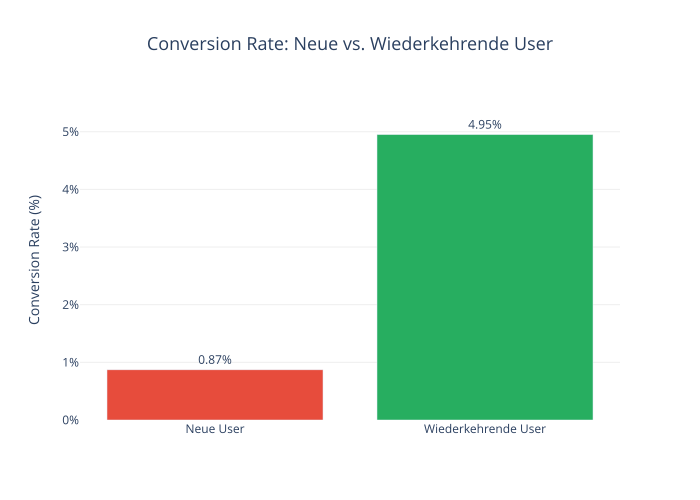

In [ ]:
fig_nr = px.bar(
    df_new_ret_pd,
    x='user_type',
    y='conversion_rate_pct',
    text=df_new_ret_pd['conversion_rate_pct'].apply(lambda x: f'{x:.2f}%'),
    color='user_type',
    color_discrete_map={'Neue User': '#e74c3c', 'Wiederkehrende User': '#27ae60'},
    labels={'user_type': '', 'conversion_rate_pct': 'Conversion Rate (%)'},
    title='Conversion Rate: Neue vs. Wiederkehrende User',
)
fig_nr.update_traces(textposition='outside')
fig_nr.update_layout(
    title_x=0.5, title_font_size=18,
    showlegend=False,
    plot_bgcolor='white', paper_bgcolor='white',
    yaxis=dict(ticksuffix='%', gridcolor='#eeeeee'),
    xaxis=dict(showgrid=False),
)
fig_nr.write_image('../figures/new_vs_returning_conversion.png', scale=2, width=600, height=400)
fig_nr.show(renderer='svg')


In [21]:
df_country = bpd.read_gbq(f"""
SELECT
  geo.country                                                                    AS country,
  COUNT(DISTINCT user_pseudo_id)                                                 AS users,
  COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL))              AS purchases,
  ROUND(COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL))
        * 100.0 / NULLIF(COUNT(DISTINCT user_pseudo_id), 0), 2)                 AS conversion_rate_pct
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  AND geo.country IS NOT NULL
  AND geo.country != ''
GROUP BY geo.country
HAVING COUNT(DISTINCT user_pseudo_id) >= 500
ORDER BY conversion_rate_pct DESC 
LIMIT 10
""")

df_country = df_country.to_pandas().sort_values('conversion_rate_pct', ascending=False)
df_country

,country,users,purchases,conversion_rate_pct
9,Netherlands,1078,20,1.86
4,Hong Kong,587,10,1.7
2,Poland,832,14,1.68
7,Japan,1270,21,1.65
8,Philippines,502,8,1.59
0,Australia,872,13,1.49
5,Taiwan,1623,24,1.48
6,Canada,7043,92,1.31
1,Spain,1781,23,1.29
3,Brazil,949,12,1.26


## 8. Revenue-Analyse

Die Kaufconversion selber sagt noch nicht allzu viel aus, aufgrund der unterschiedlichen Umsätze der Kunden, deshalb wird darauf jetzt geschaut

In [63]:
df_revenue = bpd.read_gbq(f"""
WITH purchase_events AS (
  SELECT
    CONCAT(user_pseudo_id, '-', CAST(event_timestamp AS STRING)) AS purchase_id,
    user_pseudo_id,

    COALESCE(
      (SELECT ep.value.double_value
       FROM UNNEST(event_params) ep
       WHERE ep.key = 'value'),
      CAST((
        SELECT ep.value.int_value
        FROM UNNEST(event_params) ep
        WHERE ep.key = 'value'
      ) AS FLOAT64)
    ) AS value,

    items
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE event_name = 'purchase'
    AND _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
),

purchase_revenue AS (
  SELECT
    purchase_id,
    user_pseudo_id,
    value,

    SUM(item.price * item.quantity) AS item_revenue

  FROM purchase_events,
  UNNEST(items) AS item

  GROUP BY purchase_id, user_pseudo_id, value
),

final_revenue AS (
  SELECT
    purchase_id,
    user_pseudo_id,

    -- FINAL Revenue Definition
    COALESCE(value, item_revenue) AS revenue

  FROM purchase_revenue
)

SELECT
  COUNT(DISTINCT user_pseudo_id) AS buying_users,
  COUNT(*) AS total_purchases,

  ROUND(SUM(revenue), 2) AS total_revenue,
  ROUND(AVG(revenue), 2) AS avg_order_value

FROM final_revenue
WHERE revenue IS NOT NULL
""")

df_revenue.to_pandas()


,buying_users,total_purchases,total_revenue,avg_order_value
0,819,904,57360.51,63.45


In [61]:
df_daily = bpd.read_gbq(f"""
SELECT
  event_date,
  COUNT(DISTINCT user_pseudo_id)      AS buying_users,
  ROUND(SUM(p.value.double_value), 2) AS daily_revenue,
  ROUND(AVG(p.value.double_value), 2) AS avg_order_value
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
CROSS JOIN UNNEST(event_params) AS p
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  AND event_name = 'purchase'
  AND p.key = 'value'
GROUP BY event_date
""")

df_daily = df_daily.to_pandas().sort_values('event_date').reset_index(drop=True)
df_daily

,event_date,buying_users,daily_revenue,avg_order_value
0,20210101,12,810.65,81.06
1,20210102,13,936.01,104.0
2,20210103,13,413.28,59.04
3,20210104,16,678.04,52.16
4,20210105,26,827.3,48.66
...,...,...,...,...
25,20210126,21,838.5,59.89
26,20210127,12,241.6,30.2
27,20210128,5,115.47,28.87
28,20210129,6,109.92,27.48


## Zusammenfassung

Key Findings


Business Impact


Empfehlungen
